# Tarefa

In [919]:
import numpy as np
import matplotlib.pyplot as plt

### 1

In [920]:
def funcao(x):
    return (np.e ** x) * np.cos(x)

In [921]:
def trapezio (a, b, N):
    n = N + 1 # número de pontos

    h = (b - a) / N

    xi = np.linspace(a, b, n)

    yi = funcao(xi)

    soma = 0
    for k in range (0, n):
        if k == 0 or k == n-1:
            soma += yi[k]

        else:
            soma += 2*yi[k]

    I_trap = (h/2) * soma

    print(f"N = {N} || Valor da integral: {I_trap:.5f} || Erro de: {(I_trap - 1.64877):.5f}")

In [922]:
def simps_1_3 (a, b, N):

    n = 2*N + 1 # número de pontos

    h = (b - a) / (2 * N)

    xi = np.linspace(a, b, n)

    yi = funcao(xi)

    soma = 0
    for k in range (0, n):
        if k == 0 or k == 2*N:
            soma += yi[k]

        elif k % 2 == 1:
            soma += 4 * yi[k]
        else:
            soma += 2 * yi[k]

    I_simp_1_3 = (h/3) * soma

    print(f"N = {N} || Valor da integral: {I_simp_1_3:.5f} || Erro de: {(I_simp_1_3 - 1.64877):.5f}")

In [923]:
def simpson_3_8(a, b, N):
    n = 3*N + 1 # número de pontos

    h = (b - a) / (3 * N)

    xi = np.linspace(a, b, n)

    yi = funcao(xi)

    soma = 0
    for k in range (0, n):
        if k == 0 or k == 3*N:
            soma += yi[k]

        elif k % 3 == 0:
            soma += 2 * yi[k]
        else:
            soma += 3 * yi[k]

    I_simp_3_8 = (3 * h / 8) * soma

    print(f"N = {N} || Valor da integral: {I_simp_3_8:.5f} || Erro de: {(I_simp_3_8 - 1.64877):.5f}")

### A

In [924]:
trapezio(a = 0, b = 1.2, N = 6)
trapezio(a = 0, b = 1.2, N = 24)

N = 6 || Valor da integral: 1.63915 || Erro de: -0.00962
N = 24 || Valor da integral: 1.64817 || Erro de: -0.00060


### B

In [925]:
simps_1_3(a = 0, b = 1.2, N = 3)
simps_1_3(a = 0, b = 1.2, N = 12)

N = 3 || Valor da integral: 1.64872 || Erro de: -0.00005
N = 12 || Valor da integral: 1.64877 || Erro de: 0.00000


### C

In [926]:
simpson_3_8(a = 0, b = 1.2, N = 2)
simpson_3_8(a = 0, b = 1.2, N = 8)

N = 2 || Valor da integral: 1.64864 || Erro de: -0.00013
N = 8 || Valor da integral: 1.64877 || Erro de: 0.00000


### 2

In [927]:
def funcao2(x):
    return np.sin(x)

In [928]:
def gerarPolinomio(xi, yi, grau):
    m = grau

    # número de pontos
    n = len(xi)

    # número de coeficientes do polinômio
    mn = m + 1

    u = np.zeros((n, mn))

    for i in range (0, mn):
        u[:, i] = xi ** i

    G = np.zeros((mn, mn))
    b = np.zeros(mn)

    for i in range (0, mn):
        b[i] = np.sum(u[:, i] * yi)

        for j in range (0, mn):
            G[i,j] = np.sum(u[:, i] * u[:, j])


    # resolver o sistema linear
    a = np.linalg.inv(G) @ b

    return a

def imprimirPolinomio(a, grau):
    print(f"Grau: {grau} -> {a[0]:.3f}", end="")

    for i in range (1, len(a)):
        print (f" + {a[i]:.3f}x**{i}", end="")
    
    print("\n")

In [929]:
x = np.linspace(0, 2 * np.pi, 100)
y = funcao2(x)

### A

In [930]:
coefs_g2 = gerarPolinomio(x, y, grau = 2)
imprimirPolinomio(coefs_g2, 2)

coefs_g3 = gerarPolinomio(x, y, grau = 3)
imprimirPolinomio(coefs_g3, 3)

coefs_g5 = gerarPolinomio(x, y, grau = 5)
imprimirPolinomio(coefs_g5, 5)

Grau: 2 -> 0.926 + -0.295x**1 + 0.000x**2

Grau: 3 -> -0.184 + 1.880x**1 + -0.870x**2 + 0.092x**3

Grau: 5 -> 0.013 + 0.871x**1 + 0.277x**2 + -0.398x**3 + 0.088x**4 + -0.006x**5



### B

In [931]:
def calcular_aproximacao_do_polinomio(coefs, x):
    y = np.zeros(100)
    
    for i in range (0, len(x)):
        y[i] = calcular_y(coefs, x[i])

    return y

def calcular_y(coefs, xi):
    soma = coefs[0]

    for i in range (1, len(coefs)):
        soma += coefs[i] * (xi ** i)
    
    return soma

In [932]:
y_g2 = calcular_aproximacao_do_polinomio(coefs_g2, x)
y_g3 = calcular_aproximacao_do_polinomio(coefs_g3, x)
y_g5 = calcular_aproximacao_do_polinomio(coefs_g5, x)

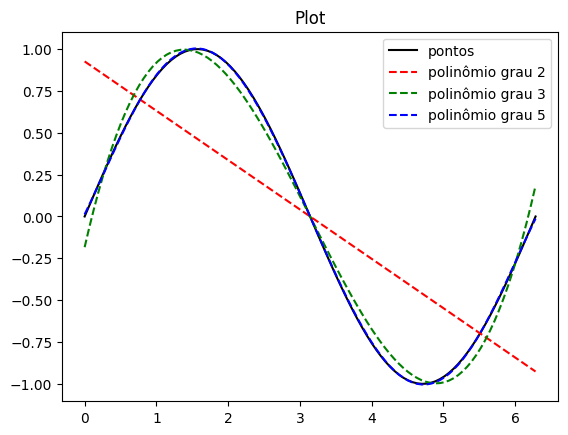

In [933]:
plt.plot(x, y, color='black', label='pontos')
plt.plot(x, y_g2, color='r', label='polinômio grau 2', linestyle='--')
plt.plot(x, y_g3, color='g', label='polinômio grau 3', linestyle='--')
plt.plot(x, y_g5, color='b', label='polinômio grau 5', linestyle='--')
plt.title('Plot')

plt.legend()
plt.show()